# Notebook 6. Bootstrap confidence intervals для feedback loop

В этом ноутбуке я дополнительно проверяю устойчивость различий между SASRec_organic_only и SASRec_nonorganic_only.

Основные метрики качества уже были рассчитаны в notebook_5_feedback_loop.ipynb`. Здесь я не переобучаю модели, а использую сохранённые per-user рекомендации: для каждого пользователя известны target-трек и top-K список рекомендаций. Это позволяет пересэмплировать пользователей с возвращением и построить bootstrap confidence intervals для Recall@K, NDCG@K и MRR@K.

Такая проверка нужна, чтобы понять, насколько различия между organic-only и nonorganic-only моделями устойчивы внутри выбранной offline-постановки.



In [1]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os
import ast
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

RANDOM_SEED = 42
N_BOOTSTRAP = 5000
CI_LEVEL = 0.95
EVAL_KS = [10, 50]

In [3]:
# путь к папке проекта
BASE_DIR = "/content/drive/MyDrive/Курсовая/final_subsample"

INPUT_DIR = f"{BASE_DIR}/notebook_5_feedback_loop_outputs"
OUTPUT_DIR = f"{BASE_DIR}/notebook_6_confidence_intervals_outputs"

RECOMMENDATIONS_PATH = f"{INPUT_DIR}/recommendations.parquet"

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Input:", RECOMMENDATIONS_PATH)
print("Output:", OUTPUT_DIR)

Input: /content/drive/MyDrive/Курсовая/final_subsample/notebook_5_feedback_loop_outputs/recommendations.parquet
Output: /content/drive/MyDrive/Курсовая/final_subsample/notebook_6_confidence_intervals_outputs


In [4]:
recommendations_df = pd.read_parquet(RECOMMENDATIONS_PATH)

print("Shape:", recommendations_df.shape)
print("Columns:", list(recommendations_df.columns))
display(recommendations_df.head())

print("\nЧисло строк по моделям:")
display(recommendations_df["model_variant"].value_counts().to_frame("n_rows"))

Shape: (9478, 5)
Columns: ['uid', 'target_idx', 'target_item', 'recommendations', 'model_variant']


,uid,target_idx,target_item,recommendations,model_variant
0,100,293,7415847,"[1143002, 1912005, 155792, 410868, 2419677, 17...",SASRec_organic_only
1,200,355,2859641,"[8729910, 500245, 4119982, 3763080, 2859641, 3...",SASRec_organic_only
2,300,60580,8033345,"[6246552, 5805912, 7247939, 8600877, 4094586, ...",SASRec_organic_only
3,600,778,5148775,"[1441281, 3397170, 1449307, 2996197, 6474571, ...",SASRec_organic_only
4,700,14457,2439431,"[7801891, 2627621, 2518515, 2188783, 1102135, ...",SASRec_organic_only



Число строк по моделям:


,n_rows
model_variant,
SASRec_organic_only,4763
SASRec_nonorganic_only,4715


## 1. Метрики на уровне пользователя

Для bootstrap нужно сначала получить значения метрик для каждого пользователя отдельно:

- hit@K: равен 1, если target попал в top-K, иначе 0
- ndcg@K: зависит от позиции target в списке
- mrr@K: обратная позиция target, если он найден.


Для начала запишем все необходимые вспомогательные функции: а именно перевод формата к листу, нормализация item id и расчет метрик hit, ndcg, mrr для одной строки recommendations_df.

In [5]:
def safe_list(x):
    if isinstance(x, list):
        return x
    if isinstance(x, tuple):
        return list(x)
    if isinstance(x, np.ndarray):
        return x.tolist()
    if pd.isna(x):
        return []
    if isinstance(x, str):
          parsed = ast.literal_eval(x)
          if isinstance(parsed, (list, tuple, np.ndarray)):
              return list(parsed)
    return list(x) if hasattr(x, "__iter__") else []

In [6]:
def normalize_id(x):
    if x is None:
        return None
    try:
        if pd.isna(x):
            return None
    except Exception:
        pass

    if isinstance(x, float) and x.is_integer():
        return str(int(x))
    return str(x)

In [7]:
def user_metrics_for_row(target_item, recommendations, k):
    target = normalize_id(target_item)
    recs = [normalize_id(item) for item in safe_list(recommendations)[:k]]

    if target is not None and target in recs:
        rank = recs.index(target) + 1
        hit = 1.0
        ndcg = 1.0 / np.log2(rank + 1)
        mrr = 1.0 / rank
    else:
        hit = 0.0
        ndcg = 0.0
        mrr = 0.0

    return hit, ndcg, mrr

In [8]:
def build_per_user_metrics(recs_df, ks=(10, 50)):
    rows = []

    for row in recs_df.itertuples(index=False):
        for k in ks:
            hit, ndcg, mrr = user_metrics_for_row(target_item=getattr(row, "target_item"), recommendations=getattr(row, "recommendations"), k=k,)
            rows.append({
                "uid": getattr(row, "uid"),
                "target_item": getattr(row, "target_item"),
                "model_variant": getattr(row, "model_variant"),
                "K": k,
                "hit": hit,
                "ndcg": ndcg,
                "mrr": mrr,})

    return pd.DataFrame(rows)

In [9]:
per_user_metrics = build_per_user_metrics(recommendations_df, ks=EVAL_KS)

print("Shape:", per_user_metrics.shape)
display(per_user_metrics.head())

# агрегированные значения должны быть близки к таблицам из основной работы
metric_check = (per_user_metrics.groupby(["model_variant", "K"]).agg(n_users=("uid", "nunique"), Recall=("hit", "mean"), NDCG=("ndcg", "mean"), MRR=("mrr", "mean"),).reset_index())

display(metric_check)

per_user_metrics.to_csv(f"{OUTPUT_DIR}/per_user_ranking_metrics.csv", index=False)

Shape: (18956, 7)


,uid,target_item,model_variant,K,hit,ndcg,mrr
0,100,7415847,SASRec_organic_only,10,0.0,0.000000,0.0
1,100,7415847,SASRec_organic_only,50,0.0,0.000000,0.0
2,200,2859641,SASRec_organic_only,10,1.0,0.386853,0.2
3,200,2859641,SASRec_organic_only,50,1.0,0.386853,0.2
4,300,8033345,SASRec_organic_only,10,0.0,0.000000,0.0


,model_variant,K,n_users,Recall,NDCG,MRR
0,SASRec_nonorganic_only,10,4715,0.048780,0.030258,0.024743
1,SASRec_nonorganic_only,50,4715,0.113256,0.044046,0.027486
2,SASRec_organic_only,10,4763,0.173840,0.111169,0.091832
3,SASRec_organic_only,50,4763,0.254671,0.129437,0.095947


## 3. Bootstrap confidence intervals

Теперь перейдем к следующему шагу, на котором пользователи уже пересэмплируются с возвращением, и для каждой метрики строится 95% доверительный интервал. Для сравнения organic-only и nonorganic-only моделей используется paired bootstrap на общих пользователях.

Теперь реализуем две основные функции для расчёта доверительных интервалов. Первая функция будет пересэмплировать значения метрики и возвращать среднее значение вместе с 95% confidence interval. Вторая применять уже эту процедуру отдельно для каждой модели, каждого значения K и каждой ranking-метрики.

In [10]:
def bootstrap_mean_ci(values, n_bootstrap=5000, ci_level=0.95, seed=42):
    values = np.asarray(values, dtype=float)
    values = values[~np.isnan(values)]

    n = len(values)
    if n == 0:
        return {
            "estimate": np.nan,
            "ci_low": np.nan,
            "ci_high": np.nan,
            "std_boot": np.nan,
            "n": 0,}

    rng = np.random.default_rng(seed)
    boot_means = np.empty(n_bootstrap)

    for b in range(n_bootstrap):
        idx = rng.integers(0, n, size=n)
        boot_means[b] = values[idx].mean()

    alpha = 1 - ci_level
    ci_low, ci_high = np.quantile(boot_means, [alpha / 2, 1 - alpha / 2])

    return {
        "estimate": float(values.mean()),
        "ci_low": float(ci_low),
        "ci_high": float(ci_high),
        "std_boot": float(boot_means.std(ddof=1)),
        "n": int(n),}

In [11]:
def bootstrap_ci_by_model(per_user_df, n_bootstrap=5000, ci_level=0.95, seed=42):
    rows = []
    metric_map = {
        "Recall": "hit",
        "NDCG": "ndcg",
        "MRR": "mrr",}

    for (model_variant, k), group in per_user_df.groupby(["model_variant", "K"]):
        for metric_name, col in metric_map.items():
            stats = bootstrap_mean_ci(group[col].values, n_bootstrap=n_bootstrap, ci_level=ci_level, seed=seed,)
            rows.append({
                "model_variant": model_variant,
                "K": k,
                "metric": f"{metric_name}@{k}",
                "estimate": stats["estimate"],
                "ci_low": stats["ci_low"],
                "ci_high": stats["ci_high"],
                "std_boot": stats["std_boot"],
                "n_users": stats["n"],
                "n_bootstrap": n_bootstrap,
                "ci_level": ci_level,
                "seed": seed,})

    return pd.DataFrame(rows)


Запустим бутсрап по моделя:

In [12]:
ci_by_model = bootstrap_ci_by_model(per_user_metrics, n_bootstrap=N_BOOTSTRAP, ci_level=CI_LEVEL, seed=RANDOM_SEED,)
display(ci_by_model)

ci_by_model.to_csv(f"{OUTPUT_DIR}/bootstrap_ci_by_model.csv", index=False)

,model_variant,K,metric,estimate,ci_low,ci_high,std_boot,n_users,n_bootstrap,ci_level,seed
0,SASRec_nonorganic_only,10,Recall@10,0.048780,0.042630,0.054724,0.003114,4715,5000,0.95,42
1,SASRec_nonorganic_only,10,NDCG@10,0.030258,0.026099,0.034591,0.002141,4715,5000,0.95,42
2,SASRec_nonorganic_only,10,MRR@10,0.024743,0.020921,0.028840,0.001992,4715,5000,0.95,42
3,SASRec_nonorganic_only,50,Recall@50,0.113256,0.104560,0.122587,0.004589,4715,5000,0.95,42
4,SASRec_nonorganic_only,50,NDCG@50,0.044046,0.039783,0.048554,0.002236,4715,5000,0.95,42
5,SASRec_nonorganic_only,50,MRR@50,0.027486,0.023638,0.031551,0.001993,4715,5000,0.95,42
6,SASRec_organic_only,10,Recall@10,0.173840,0.163132,0.184338,0.005460,4763,5000,0.95,42
7,SASRec_organic_only,10,NDCG@10,0.111169,0.103766,0.118782,0.003855,4763,5000,0.95,42
8,SASRec_organic_only,10,MRR@10,0.091832,0.084836,0.098999,0.003589,4763,5000,0.95,42
9,SASRec_organic_only,50,Recall@50,0.254671,0.242284,0.267064,0.006344,4763,5000,0.95,42


## 4. Bootstrap для сравнения моделей

Дале я считаю доверительные интервалы уже не для каждой модели отдельно, а для разницы между ними: SASRec_organic_only - SASRec_nonorganic_only.

Так как у моделей есть пересекающиеся пользователи, то используется paired bootstrap на общих пользователях. Это позволяет оценить, насколько устойчиво преимущество organic-only модели по Recall@K, NDCG@K и MRR@K.


In [13]:
def paired_difference_ci(per_user_df, model_a, model_b, metric_col, k, n_bootstrap=5000, ci_level=0.95, seed=42):
    a = per_user_df[(per_user_df["model_variant"] == model_a) & (per_user_df["K"] == k)][["uid", "target_item", metric_col]].copy()
    b = per_user_df[(per_user_df["model_variant"] == model_b) & (per_user_df["K"] == k)][["uid", "target_item", metric_col]].copy()

    merged = a.merge(b,on=["uid", "target_item"], how="inner", suffixes=("_a", "_b"),)

    if len(merged) == 0:
        return None

    diffs = merged[f"{metric_col}_a"].values - merged[f"{metric_col}_b"].values
    stats = bootstrap_mean_ci(diffs, n_bootstrap=n_bootstrap, ci_level=ci_level, seed=seed,)

    stats["n_paired"] = int(len(merged))
    return stats

In [14]:
def independent_difference_ci(per_user_df, model_a, model_b, metric_col, k, n_bootstrap=5000, ci_level=0.95, seed=42):
    a = per_user_df[(per_user_df["model_variant"] == model_a) & (per_user_df["K"] == k)][metric_col].dropna().values
    b = per_user_df[(per_user_df["model_variant"] == model_b) & (per_user_df["K"] == k)][metric_col].dropna().values

    rng = np.random.default_rng(seed)
    boot_diffs = np.empty(n_bootstrap)

    for i in range(n_bootstrap):
        sample_a = a[rng.integers(0, len(a), size=len(a))]
        sample_b = b[rng.integers(0, len(b), size=len(b))]
        boot_diffs[i] = sample_a.mean() - sample_b.mean()

    alpha = 1 - ci_level
    ci_low, ci_high = np.quantile(boot_diffs, [alpha / 2, 1 - alpha / 2])

    return {
        "estimate": float(a.mean() - b.mean()),
        "ci_low": float(ci_low),
        "ci_high": float(ci_high),
        "std_boot": float(boot_diffs.std(ddof=1)),
        "n_a": int(len(a)),
        "n_b": int(len(b)),}

In [15]:
def bootstrap_model_differences(
    per_user_df,
    model_a="SASRec_organic_only",
    model_b="SASRec_nonorganic_only",
    n_bootstrap=5000,
    ci_level=0.95,
    seed=42,
    min_paired_n=100,):
    metric_map = {
        "Recall": "hit",
        "NDCG": "ndcg",
        "MRR": "mrr",}

    rows = []

    for k in sorted(per_user_df["K"].unique()):
        for metric_name, metric_col in metric_map.items():
            paired_stats = paired_difference_ci(per_user_df, model_a=model_a, model_b=model_b, metric_col=metric_col, k=k, n_bootstrap=n_bootstrap, ci_level=ci_level, seed=seed,)
            if paired_stats is not None and paired_stats["n_paired"] >= min_paired_n:
                stats = paired_stats
                method = "paired_bootstrap_on_common_users"
                n_info = f"n_paired={paired_stats['n_paired']}"
            else:
                stats = independent_difference_ci(per_user_df,model_a=model_a,model_b=model_b,metric_col=metric_col,k=k,n_bootstrap=n_bootstrap,ci_level=ci_level,seed=seed,)
                method = "independent_bootstrap"
                n_info = f"n_a={stats['n_a']}; n_b={stats['n_b']}"

            rows.append({
                "model_a": model_a,
                "model_b": model_b,
                "difference": f"{model_a} - {model_b}",
                "K": k,
                "metric": f"{metric_name}@{k}",
                "estimate_diff": stats["estimate"],
                "ci_low": stats["ci_low"],
                "ci_high": stats["ci_high"],
                "std_boot": stats["std_boot"],
                "method": method,
                "n_info": n_info,
                "n_bootstrap": n_bootstrap,
                "ci_level": ci_level,
                "seed": seed,
                "ci_excludes_zero": bool(stats["ci_low"] > 0 or stats["ci_high"] < 0),})

    return pd.DataFrame(rows)

Теперь запустим бутстрап для разницы organic-only и nonorganic-only

In [16]:
ci_differences = bootstrap_model_differences(per_user_metrics, model_a="SASRec_organic_only", model_b="SASRec_nonorganic_only", n_bootstrap=N_BOOTSTRAP, ci_level=CI_LEVEL, seed=RANDOM_SEED,)
display(ci_differences)

ci_differences.to_csv(f"{OUTPUT_DIR}/bootstrap_ci_model_differences.csv", index=False)

,model_a,model_b,difference,K,metric,estimate_diff,ci_low,ci_high,std_boot,method,n_info,n_bootstrap,ci_level,seed,ci_excludes_zero
0,SASRec_organic_only,SASRec_nonorganic_only,SASRec_organic_only - SASRec_nonorganic_only,10,Recall@10,0.124528,0.112542,0.136293,0.006065,paired_bootstrap_on_common_users,n_paired=4505,5000,0.95,42,True
1,SASRec_organic_only,SASRec_nonorganic_only,SASRec_organic_only - SASRec_nonorganic_only,10,NDCG@10,0.080742,0.072625,0.088757,0.004204,paired_bootstrap_on_common_users,n_paired=4505,5000,0.95,42,True
2,SASRec_organic_only,SASRec_nonorganic_only,SASRec_organic_only - SASRec_nonorganic_only,10,MRR@10,0.067019,0.059392,0.074557,0.003924,paired_bootstrap_on_common_users,n_paired=4505,5000,0.95,42,True
3,SASRec_organic_only,SASRec_nonorganic_only,SASRec_organic_only - SASRec_nonorganic_only,50,Recall@50,0.142064,0.127414,0.157159,0.007436,paired_bootstrap_on_common_users,n_paired=4505,5000,0.95,42,True
4,SASRec_organic_only,SASRec_nonorganic_only,SASRec_organic_only - SASRec_nonorganic_only,50,NDCG@50,0.085481,0.077363,0.093679,0.004218,paired_bootstrap_on_common_users,n_paired=4505,5000,0.95,42,True
5,SASRec_organic_only,SASRec_nonorganic_only,SASRec_organic_only - SASRec_nonorganic_only,50,MRR@50,0.068444,0.060837,0.075955,0.003903,paired_bootstrap_on_common_users,n_paired=4505,5000,0.95,42,True


## 5. Основные результаты

Теперь посмотрим на основные результаты:


In [17]:
ci_text_table = (ci_by_model[ci_by_model["K"] == 50].copy().sort_values(["metric", "model_variant"]))
ci_text_table["estimate_with_ci"] = ci_text_table.apply(lambda r: f"{r['estimate']:.4f} [{r['ci_low']:.4f}; {r['ci_high']:.4f}]", axis=1,)

ci_text_table_1 = ci_text_table[["model_variant", "metric", "estimate_with_ci", "n_users", "n_bootstrap"]]
display(ci_text_table_1)

ci_text_table_1.to_csv(f"{OUTPUT_DIR}/table_for_ci_k50.csv", index=False)

,model_variant,metric,estimate_with_ci,n_users,n_bootstrap
5,SASRec_nonorganic_only,MRR@50,0.0275 [0.0236; 0.0316],4715,5000
11,SASRec_organic_only,MRR@50,0.0959 [0.0891; 0.1031],4763,5000
4,SASRec_nonorganic_only,NDCG@50,0.0440 [0.0398; 0.0486],4715,5000
10,SASRec_organic_only,NDCG@50,0.1294 [0.1222; 0.1373],4763,5000
3,SASRec_nonorganic_only,Recall@50,0.1133 [0.1046; 0.1226],4715,5000
9,SASRec_organic_only,Recall@50,0.2547 [0.2423; 0.2671],4763,5000


In [18]:
diff_text_table = ci_differences[ci_differences["K"] == 50].copy()
diff_text_table["diff_with_ci"] = diff_text_table.apply(lambda r: f"{r['estimate_diff']:.4f} [{r['ci_low']:.4f}; {r['ci_high']:.4f}]",axis=1,)
diff_text_table_2 = diff_text_table[["difference", "metric", "diff_with_ci", "method", "n_info", "ci_excludes_zero"]]

display(diff_text_table_2)

diff_text_table_2.to_csv(f"{OUTPUT_DIR}/table_differences_k50.csv", index=False)

,difference,metric,diff_with_ci,method,n_info,ci_excludes_zero
3,SASRec_organic_only - SASRec_nonorganic_only,Recall@50,0.1421 [0.1274; 0.1572],paired_bootstrap_on_common_users,n_paired=4505,True
4,SASRec_organic_only - SASRec_nonorganic_only,NDCG@50,0.0855 [0.0774; 0.0937],paired_bootstrap_on_common_users,n_paired=4505,True
5,SASRec_organic_only - SASRec_nonorganic_only,MRR@50,0.0684 [0.0608; 0.0760],paired_bootstrap_on_common_users,n_paired=4505,True


Визуализируем наши результаты:


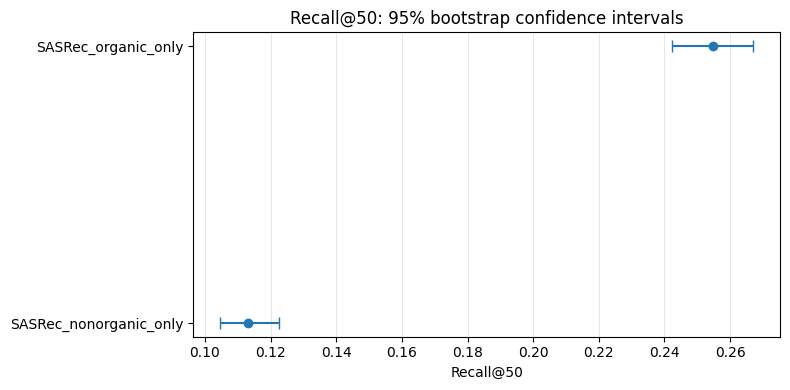

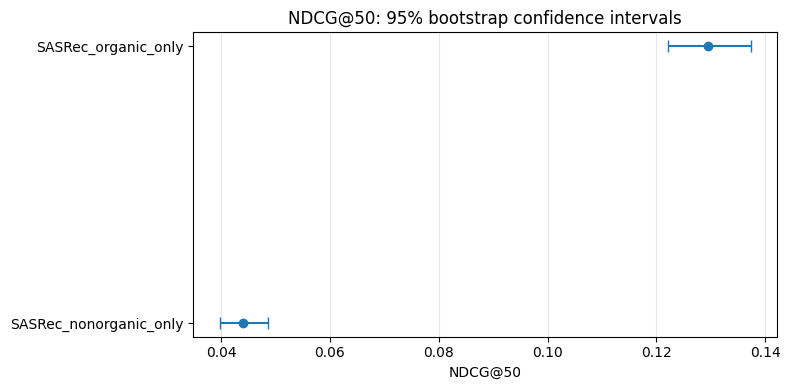

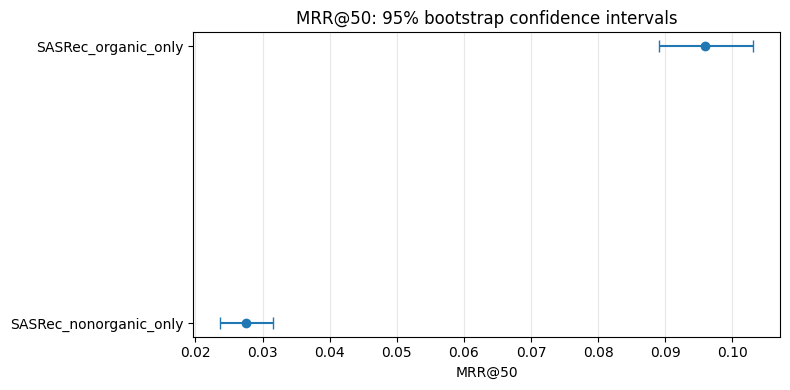

In [19]:
plot_df = ci_by_model[ci_by_model["K"] == 50].copy()

for metric in plot_df["metric"].unique():
    tmp = plot_df[plot_df["metric"] == metric].copy().sort_values("model_variant")

    y = np.arange(len(tmp))
    x = tmp["estimate"].values
    xerr_low = x - tmp["ci_low"].values
    xerr_high = tmp["ci_high"].values - x

    plt.figure(figsize=(8, 4))
    plt.errorbar(x, y, xerr=[xerr_low, xerr_high], fmt="o", capsize=4)
    plt.yticks(y, tmp["model_variant"])
    plt.xlabel(metric)
    plt.title(f"{metric}: 95% bootstrap confidence intervals")
    plt.grid(axis="x", alpha=0.3)
    plt.tight_layout()

    out_path = f"{OUTPUT_DIR}/{metric.replace('@', '_at_')}_ci_plot.png"
    plt.savefig(out_path, dpi=200)
    plt.show()

**Вывод:** Итак, как видно из таблиц и визуализации, SASRec_organic_only устойчиво превосходит SASRec_nonorganic_only по всем трём ranking-метрикам при (K=50). Для Recall@50 значение organic-only модели составляет 0.2547 против 0.1133 у nonorganic-only, для NDCG@50 - 0.1294 против 0.0440, для MRR@50 - 0.0959 против 0.0275.

Bootstrap-проверка показывает, что эти различия не сводятся к случайной вариации test-пользователей. Разница между моделями составляет 0.1421 для Recall@50, 0.0855 для NDCG@50 и 0.0684 для MRR@50. Более того, во всех трёх случаях 95% доверительные интервалы для разницы не включают ноль.

Следовательно, в рамках выбранной offline-постановки organic-взаимодействия дают более сильный обучающий сигнал, чем non-organic-взаимодействия.